# 03. Анализ ошибок и потерянного сигнала — V1

## Главный исследовательский вопрос

**Есть ли в OOF-прогнозах baseline без `Q_B1_norm` и `Q_B2_norm` устойчивые группы ошибок, которые одинаково видят CatBoost, XGBoost и LightGBM, и чем эти общие слепые зоны отличаются по доступным признакам от хорошо ранжированных наблюдений?**

### Зачем это нужно

Stage 1 показал честный baseline около **Gini 0.804**. Stage 2 показал, что три модели опираются на очень похожее ядро признаков. Следующий шаг — понять не только **что модели знают**, но и **где они систематически ошибаются**.

Если разные модели делают похожие ошибки на одних и тех же наблюдениях, это сильнее указывает на общий информационный пробел, чем на недостаток одной конкретной реализации бустинга.

### Контролируемый эксперимент

Фиксируются:

- тот же dataset и SHA-256;
- те же 47 допустимых признаков;
- тот же working/final split;
- те же 3 внешних CV-фолда;
- `seed = 42`;
- те же параметры CatBoost, XGBoost и LightGBM;
- тот же протокол early stopping и refit;
- final test остаётся закрытым;
- threshold не подбирается и не используется для определения ошибок.

### Как определяем трудные случаи

Чтобы не зависеть от калибровки вероятностей разных моделей, сравниваем **OOF percentile-rank риска**.

- `1.0` — наблюдение среди самых рискованных;
- `0.0` — среди наименее рискованных.

Заранее фиксируем диагностические группы:

- **глубоко пропущенный дефолт**: `DefMark = 1`, consensus rank ≤ 0.50;
- **хорошо ранжированный дефолт**: `DefMark = 1`, consensus rank ≥ 0.90;
- **высокорисковый недефолт**: `DefMark = 0`, consensus rank ≥ 0.95;
- **общая слепая зона**: глубоко пропущенный дефолт, при этом разброс rank между тремя моделями ≤ 0.10;
- **сильное межмодельное расхождение**: разброс rank ≥ 0.25.

Эти границы используются только для диагностики структуры ошибок и **не являются рабочим threshold**.


In [3]:
from __future__ import annotations

import hashlib
import importlib.metadata as importlib_metadata
import json
import platform
from pathlib import Path
from time import perf_counter
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier, early_stopping
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from xgboost import XGBClassifier


def найти_корень_проекта(начало: Path | None = None) -> Path:
    """Находит корень проекта по файлу pyproject.toml."""
    текущая = (начало or Path.cwd()).resolve()
    for кандидат in [текущая, *текущая.parents]:
        if (кандидат / "pyproject.toml").exists():
            return кандидат
    raise FileNotFoundError("Не найден корень проекта с pyproject.toml.")


def вычислить_sha256(путь: Path, размер_блока: int = 1024 * 1024) -> str:
    """Вычисляет SHA-256 файла блоками."""
    хэш = hashlib.sha256()
    with путь.open("rb") as файл:
        for блок in iter(lambda: файл.read(размер_блока), b""):
            хэш.update(блок)
    return хэш.hexdigest()


def хэш_массива(значения: np.ndarray) -> str:
    """Вычисляет SHA-256 массива индексов."""
    массив = np.asarray(значения, dtype=np.int64)
    return hashlib.sha256(массив.tobytes()).hexdigest()


КОРЕНЬ_ПРОЕКТА = найти_корень_проекта()
ПУТЬ_К_ДАТАСЕТУ = КОРЕНЬ_ПРОЕКТА / "data" / "raw" / "Data_final.xlsb"
ПАПКА_ОТЧЁТОВ = КОРЕНЬ_ПРОЕКТА / "reports" / "generated"
ПАПКА_ОТЧЁТОВ.mkdir(parents=True, exist_ok=True)

ОЖИДАЕМЫЙ_SHA256 = "fc742be66d238c529daba52ccc755f774f836b7d052ed062cdf0b345080e7930"
ОЖИДАЕМЫЙ_SHA_РАБОТА = "80430ce6290d0982d3641621ba1ed62f6fb495e8d32f7d23d9fca00091aadb45"
ОЖИДАЕМЫЙ_SHA_TEST = "35ec963fe82918841f4a8acb012e8fc878aed66d2c5296ea6cb105177cafbb37"

ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ = "DefMark"
ИДЕНТИФИКАТОР = "INN"
ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ = ["Q_B1_norm", "Q_B2_norm"]

ДОЛЯ_ФИНАЛЬНОГО_TEST = 0.20
ЧИСЛО_ФОЛДОВ = 3
СЛУЧАЙНОЕ_ЗЕРНО = 42
РАННЯЯ_ОСТАНОВКА = 40
ДОЛЯ_ВНУТРЕННЕЙ_ВАЛИДАЦИИ = 0.10
ЧИСЛО_ПОТОКОВ = -1
ПРЕДЕЛ_ОТКЛОНЕНИЯ_GINI = 0.003

ГРАНИЦА_ГЛУБОКОГО_ПРОПУСКА = 0.50
ГРАНИЦА_ХОРОШЕГО_ДЕФОЛТА = 0.90
ГРАНИЦА_ВЫСОКОГО_РИСКА_НЕДЕФОЛТА = 0.95
МАКС_РАЗБРОС_ОБЩЕЙ_СЛЕПОЙ_ЗОНЫ = 0.10
МИН_РАЗБРОС_СИЛЬНОГО_РАСХОЖДЕНИЯ = 0.25

ОЖИДАЕМЫЙ_GINI_V2 = {
    "CatBoost": 0.803779690692136,
    "XGBoost": 0.8039898778800276,
    "LightGBM": 0.8033629488861926,
}

TOP10_STAGE2 = [
    "Q_D6_norm",
    "Q_A5_norm",
    "Q_B3_norm",
    "Q_C1_norm",
    "G1_norm",
    "Q_D4_norm",
    "D5_norm",
    "A4_norm",
    "C4_norm",
    "Q_A4_norm",
]

print("Корень проекта:", КОРЕНЬ_ПРОЕКТА)
print("Python:", platform.python_version())
print("Dataset:", ПУТЬ_К_ДАТАСЕТУ)
print("Фолдов:", ЧИСЛО_ФОЛДОВ)
print("Seed:", СЛУЧАЙНОЕ_ЗЕРНО)

Корень проекта: D:\Projects\komus-credit-risk
Python: 3.12.2
Dataset: D:\Projects\komus-credit-risk\data\raw\Data_final.xlsb
Фолдов: 3
Seed: 42


### Анализ настройки

Stage 3 не меняет baseline и не выбирает новую модель. Мы воспроизводим принятый OOF-протокол только для того, чтобы получить честные row-level OOF-прогнозы и исследовать структуру ошибок.

Главное отличие от обычной confusion matrix: здесь нет зависимости от произвольного порога `0.5`. Анализ строится на относительном положении компании в ранжировании риска.


# 1. Проверка dataset и split

## Исследовательский вопрос

Использует ли Stage 3 точно тот же dataset, feature set и working/final split, что и принятый Stage 1 V2?


In [4]:
if not ПУТЬ_К_ДАТАСЕТУ.exists():
    raise FileNotFoundError(f"Dataset не найден: {ПУТЬ_К_ДАТАСЕТУ}")

фактический_sha256 = вычислить_sha256(ПУТЬ_К_ДАТАСЕТУ)
if фактический_sha256.lower() != ОЖИДАЕМЫЙ_SHA256.lower():
    raise RuntimeError(
        "SHA-256 dataset не совпал с принятым baseline.\n"
        f"Ожидался: {ОЖИДАЕМЫЙ_SHA256}\n"
        f"Получен:  {фактический_sha256}"
    )

начало_чтения = perf_counter()
данные = pd.read_excel(
    ПУТЬ_К_ДАТАСЕТУ,
    engine="pyxlsb",
    sheet_name="Data_final",
).reset_index(drop=True)
время_чтения = perf_counter() - начало_чтения

обязательные = {ИДЕНТИФИКАТОР, ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ, *ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ}
отсутствующие = обязательные.difference(данные.columns)
if отсутствующие:
    raise KeyError(f"Отсутствуют обязательные столбцы: {sorted(отсутствующие)}")

данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ] = pd.to_numeric(
    данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ], errors="raise"
).astype("int8")

ВСЕ_МОДЕЛЬНЫЕ_ПРИЗНАКИ = [
    столбец
    for столбец in данные.columns
    if столбец not in {ИДЕНТИФИКАТОР, ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ}
]

ДОПУСТИМЫЕ_ПРИЗНАКИ = [
    столбец
    for столбец in ВСЕ_МОДЕЛЬНЫЕ_ПРИЗНАКИ
    if столбец not in ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ
]

for столбец in ДОПУСТИМЫЕ_ПРИЗНАКИ:
    данные[столбец] = pd.to_numeric(
        данные[столбец], errors="raise"
    ).astype("float32")

if len(ВСЕ_МОДЕЛЬНЫЕ_ПРИЗНАКИ) != 49:
    raise RuntimeError(
        f"Ожидалось 49 исходных признаков, получено {len(ВСЕ_МОДЕЛЬНЫЕ_ПРИЗНАКИ)}."
    )

if len(ДОПУСТИМЫЕ_ПРИЗНАКИ) != 47:
    raise RuntimeError(
        f"Ожидалось 47 допустимых признаков, получено {len(ДОПУСТИМЫЕ_ПРИЗНАКИ)}."
    )

if set(ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ).intersection(ДОПУСТИМЫЕ_ПРИЗНАКИ):
    raise RuntimeError("Закрытые индексы попали в допустимый feature set.")

if int(данные[ДОПУСТИМЫЕ_ПРИЗНАКИ].isna().sum().sum()) != 0:
    raise RuntimeError("В допустимых признаках появились пропуски.")

if int(данные[ИДЕНТИФИКАТОР].duplicated().sum()) != 0:
    raise RuntimeError("В dataset появились дубликаты INN.")

X_все = данные[ДОПУСТИМЫЕ_ПРИЗНАКИ]
y_все = данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ]

индексы = np.arange(len(данные))
индексы_работа, индексы_test = train_test_split(
    индексы,
    test_size=ДОЛЯ_ФИНАЛЬНОГО_TEST,
    stratify=y_все,
    random_state=СЛУЧАЙНОЕ_ЗЕРНО,
)

SHA_ИНДЕКСОВ_РАБОТА = хэш_массива(индексы_работа)
SHA_ИНДЕКСОВ_TEST = хэш_массива(индексы_test)

if SHA_ИНДЕКСОВ_РАБОТА != ОЖИДАЕМЫЙ_SHA_РАБОТА:
    raise RuntimeError("Working split не совпал со Stage 1 V2.")

if SHA_ИНДЕКСОВ_TEST != ОЖИДАЕМЫЙ_SHA_TEST:
    raise RuntimeError("Final test split не совпал со Stage 1 V2.")

# Final test намеренно не материализуется в X_test / y_test.
X_работа = X_все.iloc[индексы_работа].reset_index(drop=True)
y_работа = y_все.iloc[индексы_работа].reset_index(drop=True)

КРОСС_ВАЛИДАЦИЯ = StratifiedKFold(
    n_splits=ЧИСЛО_ФОЛДОВ,
    shuffle=True,
    random_state=СЛУЧАЙНОЕ_ЗЕРНО,
)
ФОЛДЫ = list(КРОСС_ВАЛИДАЦИЯ.split(X_работа, y_работа))

ПАСПОРТ = pd.DataFrame([
    ("SHA-256 dataset", фактический_sha256),
    ("Строк dataset", len(данные)),
    ("Допустимых признаков", len(ДОПУСТИМЫЕ_ПРИЗНАКИ)),
    ("Рабочих строк", len(индексы_работа)),
    ("Final test строк", len(индексы_test)),
    ("SHA working split", SHA_ИНДЕКСОВ_РАБОТА),
    ("SHA final test split", SHA_ИНДЕКСОВ_TEST),
    ("Время чтения, сек", round(время_чтения, 3)),
], columns=["Проверка", "Значение"])

display(ПАСПОРТ)
print("Final test зафиксирован и остаётся закрытым.")

,Проверка,Значение
0,SHA-256 dataset,fc742be66d238c529daba52ccc755f774f836b7d052ed0...
1,Строк dataset,362018
2,Допустимых признаков,47
3,Рабочих строк,289614
4,Final test строк,72404
5,SHA working split,80430ce6290d0982d3641621ba1ed62f6fb495e8d32f7d...
6,SHA final test split,35ec963fe82918841f4a8acb012e8fc878aed66d2c5296...
7,"Время чтения, сек",137.335


Final test зафиксирован и остаётся закрытым.


### Вывод

Если эта ячейка завершилась без исключения, Stage 3 использует тот же dataset и тот же split-контракт, что и принятый baseline. Любое несовпадение SHA останавливает исследование до обучения моделей.


# 2. Воспроизведение OOF-прогнозов трёх моделей

## Исследовательский вопрос

Получаем ли мы те же OOF Gini, что и в Stage 1 V2, прежде чем анализировать ошибки?

Это обязательный gate: если качество заметно разошлось, дальнейшая диагностика уже относится к другому эксперименту.


In [5]:
ПАРАМЕТРЫ_МОДЕЛЕЙ: dict[str, dict[str, Any]] = {
    "CatBoost": {
        "iterations": 900,
        "learning_rate": 0.06,
        "depth": 7,
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "thread_count": ЧИСЛО_ПОТОКОВ,
        "verbose": False,
        "allow_writing_files": False,
    },
    "XGBoost": {
        "n_estimators": 900,
        "learning_rate": 0.06,
        "max_depth": 6,
        "min_child_weight": 3,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.05,
        "reg_lambda": 1.0,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "n_jobs": ЧИСЛО_ПОТОКОВ,
        "tree_method": "hist",
    },
    "LightGBM": {
        "n_estimators": 900,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 40,
        "subsample": 0.85,
        "subsample_freq": 1,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.05,
        "reg_lambda": 1.0,
        "n_jobs": ЧИСЛО_ПОТОКОВ,
        "verbosity": -1,
    },
}


def внутреннее_разбиение(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Создаёт внутреннюю validation-часть только внутри внешнего train-фолда."""
    локальные_индексы = np.arange(len(X_train))
    индексы_fit, индексы_early_stop = train_test_split(
        локальные_индексы,
        test_size=ДОЛЯ_ВНУТРЕННЕЙ_ВАЛИДАЦИИ,
        stratify=y_train,
        random_state=seed,
    )
    return (
        X_train.iloc[индексы_fit],
        X_train.iloc[индексы_early_stop],
        y_train.iloc[индексы_fit],
        y_train.iloc[индексы_early_stop],
    )


def обучить_catboost(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    seed: int,
) -> tuple[CatBoostClassifier, int]:
    """Воспроизводит CatBoost-протокол Stage 1 V2."""
    X_fit, X_es, y_fit, y_es = внутреннее_разбиение(X_train, y_train, seed)
    параметры = ПАРАМЕТРЫ_МОДЕЛЕЙ["CatBoost"].copy()

    поиск = CatBoostClassifier(**параметры, random_seed=seed)
    поиск.fit(
        X_fit,
        y_fit,
        eval_set=(X_es, y_es),
        early_stopping_rounds=РАННЯЯ_ОСТАНОВКА,
        verbose=False,
    )

    лучшая = поиск.get_best_iteration()
    число_итераций = (
        int(лучшая) + 1
        if лучшая is not None and int(лучшая) >= 0
        else int(параметры["iterations"])
    )

    параметры["iterations"] = число_итераций
    модель = CatBoostClassifier(**параметры, random_seed=seed)
    модель.fit(X_train, y_train)
    return модель, число_итераций


def обучить_xgboost(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    seed: int,
) -> tuple[XGBClassifier, int]:
    """Воспроизводит XGBoost-протокол Stage 1 V2."""
    X_fit, X_es, y_fit, y_es = внутреннее_разбиение(X_train, y_train, seed)
    параметры = ПАРАМЕТРЫ_МОДЕЛЕЙ["XGBoost"].copy()

    поиск = XGBClassifier(
        **параметры,
        random_state=seed,
        early_stopping_rounds=РАННЯЯ_ОСТАНОВКА,
    )
    поиск.fit(
        X_fit,
        y_fit,
        eval_set=[(X_es, y_es)],
        verbose=False,
    )

    лучшая = getattr(поиск, "best_iteration", None)
    число_итераций = (
        int(лучшая) + 1
        if лучшая is not None
        else int(параметры["n_estimators"])
    )

    параметры["n_estimators"] = число_итераций
    модель = XGBClassifier(**параметры, random_state=seed)
    модель.fit(X_train, y_train)
    return модель, число_итераций


def обучить_lightgbm(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    seed: int,
) -> tuple[LGBMClassifier, int]:
    """Воспроизводит LightGBM-протокол Stage 1 V2."""
    X_fit, X_es, y_fit, y_es = внутреннее_разбиение(X_train, y_train, seed)
    параметры = ПАРАМЕТРЫ_МОДЕЛЕЙ["LightGBM"].copy()

    поиск = LGBMClassifier(**параметры, random_state=seed)
    поиск.fit(
        X_fit,
        y_fit,
        eval_X=X_es,
        eval_y=y_es,
        callbacks=[early_stopping(РАННЯЯ_ОСТАНОВКА, verbose=False)],
    )

    лучшая = getattr(поиск, "best_iteration_", None)
    число_итераций = (
        int(лучшая)
        if лучшая is not None and int(лучшая) > 0
        else int(параметры["n_estimators"])
    )

    параметры["n_estimators"] = число_итераций
    модель = LGBMClassifier(**параметры, random_state=seed)
    модель.fit(X_train, y_train)
    return модель, число_итераций


def обучить_модель(
    название: str,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    seed: int,
) -> tuple[Any, int]:
    """Вызывает строго определённую ветку обучения нужной модели."""
    if название == "CatBoost":
        return обучить_catboost(X_train, y_train, seed)
    if название == "XGBoost":
        return обучить_xgboost(X_train, y_train, seed)
    if название == "LightGBM":
        return обучить_lightgbm(X_train, y_train, seed)
    raise KeyError(f"Неизвестная модель: {название}")

In [6]:
МОДЕЛИ = ["CatBoost", "XGBoost", "LightGBM"]
OOF_ПРОГНОЗЫ: dict[str, np.ndarray] = {
    название: np.full(len(X_работа), np.nan, dtype=np.float64)
    for название in МОДЕЛИ
}

строки_фолдов: list[dict[str, Any]] = []
начало_эксперимента = perf_counter()

for название in МОДЕЛИ:
    print("\n" + "=" * 72)
    print(f"Модель: {название}")
    print("=" * 72)

    for номер_фолда, (train_idx, valid_idx) in enumerate(ФОЛДЫ, start=1):
        X_train = X_работа.iloc[train_idx]
        y_train = y_работа.iloc[train_idx]
        X_valid = X_работа.iloc[valid_idx]
        y_valid = y_работа.iloc[valid_idx]

        seed = СЛУЧАЙНОЕ_ЗЕРНО + номер_фолда
        начало = perf_counter()
        модель, число_итераций = обучить_модель(
            название,
            X_train,
            y_train,
            seed,
        )
        время_обучения = perf_counter() - начало

        вероятности = np.asarray(
            модель.predict_proba(X_valid),
            dtype=np.float64,
        )[:, 1]

        OOF_ПРОГНОЗЫ[название][valid_idx] = вероятности

        roc_auc = float(roc_auc_score(y_valid, вероятности))
        gini = float(2 * roc_auc - 1)

        строки_фолдов.append({
            "Модель": название,
            "Фолд": номер_фолда,
            "Gini": gini,
            "Лучшая итерация": int(число_итераций),
            "Время обучения, сек": float(время_обучения),
        })

        print(
            f"{название} · фолд {номер_фолда}: "
            f"Gini={gini:.4f}; "
            f"итераций={число_итераций}; "
            f"обучение={время_обучения:.1f} сек."
        )

for название, oof in OOF_ПРОГНОЗЫ.items():
    if np.isnan(oof).any():
        raise RuntimeError(f"OOF-прогнозы {название} заполнены не полностью.")

строки_качества: list[dict[str, Any]] = []

for название in МОДЕЛИ:
    oof = OOF_ПРОГНОЗЫ[название]
    roc_auc = float(roc_auc_score(y_работа, oof))
    gini = float(2 * roc_auc - 1)
    pr_auc = float(average_precision_score(y_работа, oof))
    отклонение = float(gini - ОЖИДАЕМЫЙ_GINI_V2[название])

    if abs(отклонение) > ПРЕДЕЛ_ОТКЛОНЕНИЯ_GINI:
        raise RuntimeError(
            f"{название}: Gini отклонился от Stage 1 V2 на {отклонение:.4f}, "
            f"что больше допустимых {ПРЕДЕЛ_ОТКЛОНЕНИЯ_GINI:.4f}."
        )

    строки_качества.append({
        "Модель": название,
        "ROC-AUC OOF": roc_auc,
        "Gini OOF": gini,
        "PR-AUC OOF": pr_auc,
        "Gini Stage 1 V2": ОЖИДАЕМЫЙ_GINI_V2[название],
        "Отклонение Gini": отклонение,
    })

ТАБЛИЦА_ВОСПРОИЗВЕДЕНИЯ = pd.DataFrame(строки_качества)
ТАБЛИЦА_ФОЛДОВ = pd.DataFrame(строки_фолдов)
ОБЩЕЕ_ВРЕМЯ_ОБУЧЕНИЯ = perf_counter() - начало_эксперимента

display(ТАБЛИЦА_ВОСПРОИЗВЕДЕНИЯ.round(4))
print(f"Общее время воспроизведения OOF: {ОБЩЕЕ_ВРЕМЯ_ОБУЧЕНИЯ:.1f} сек.")


Модель: CatBoost
CatBoost · фолд 1: Gini=0.7965; итераций=531; обучение=63.4 сек.
CatBoost · фолд 2: Gini=0.8051; итераций=607; обучение=75.4 сек.
CatBoost · фолд 3: Gini=0.8097; итераций=760; обучение=93.4 сек.

Модель: XGBoost
XGBoost · фолд 1: Gini=0.7974; итераций=417; обучение=20.4 сек.
XGBoost · фолд 2: Gini=0.8060; итераций=395; обучение=20.0 сек.
XGBoost · фолд 3: Gini=0.8088; итераций=434; обучение=22.2 сек.

Модель: LightGBM
LightGBM · фолд 1: Gini=0.7974; итераций=639; обучение=24.1 сек.
LightGBM · фолд 2: Gini=0.8048; итераций=449; обучение=19.6 сек.
LightGBM · фолд 3: Gini=0.8083; итераций=456; обучение=21.2 сек.


,Модель,ROC-AUC OOF,Gini OOF,PR-AUC OOF,Gini Stage 1 V2,Отклонение Gini
0,CatBoost,0.9019,0.8038,0.6010,0.8038,0.0
1,XGBoost,0.9020,0.8040,0.5993,0.8040,0.0
2,LightGBM,0.9017,0.8034,0.5978,0.8034,0.0


Общее время воспроизведения OOF: 365.3 сек.


### Вывод по gate воспроизводимости

Если ячейка завершилась без `RuntimeError`, все три OOF Gini находятся в заранее заданном допуске относительно Stage 1 V2. Только после этого переходим к диагностике ошибок.


# 3. Consensus risk rank без выбора threshold

## Исследовательский вопрос

Где в общем OOF-ранжировании оказываются дефолтные компании и насколько сильно расходятся три модели по одним и тем же наблюдениям?

Чтобы не смешивать ранжирование с калибровкой, вероятности каждой модели преобразуются в percentile-rank, а затем усредняются.


,Дециль риска,Число дефолтов,"Доля всех дефолтов, %"
0,1,74,0.26
1,2,131,0.47
2,3,227,0.81
3,4,337,1.20
4,5,509,1.82
5,6,795,2.84
6,7,1462,5.22
7,8,2676,9.55
8,9,5778,20.62
9,10,16026,57.21


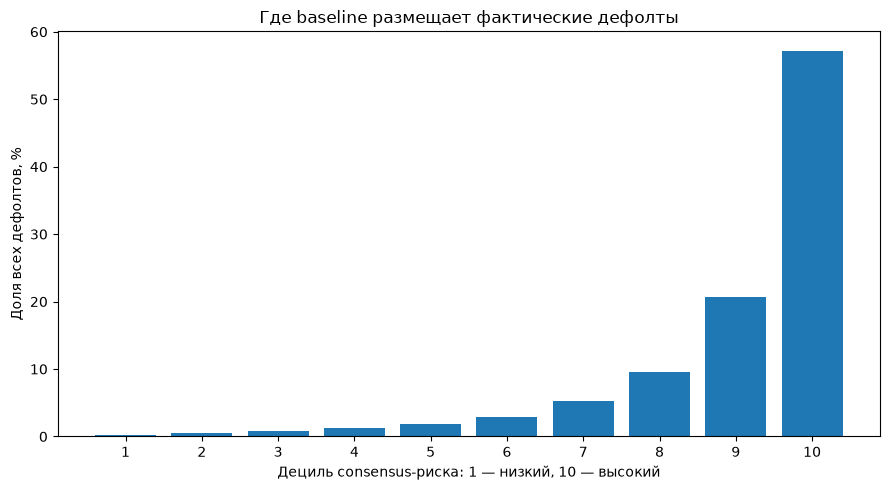

Дефолтов в top-10% риска: 57.2%
Дефолтов в top-20% риска: 77.8%
Дефолтов в top-30% риска: 87.4%


In [7]:
def percentile_rank(значения: np.ndarray) -> np.ndarray:
    """Преобразует score в percentile-rank от 0 до 1."""
    return (
        pd.Series(np.asarray(значения, dtype=np.float64))
        .rank(method="average", pct=True)
        .to_numpy(dtype=np.float64)
    )


РАНГИ_МОДЕЛЕЙ = {
    название: percentile_rank(OOF_ПРОГНОЗЫ[название])
    for название in МОДЕЛИ
}

матрица_рангов = np.column_stack([
    РАНГИ_МОДЕЛЕЙ[название] for название in МОДЕЛИ
])

CONSENSUS_RANK = матрица_рангов.mean(axis=1)
РАЗБРОС_РАНГОВ = матрица_рангов.max(axis=1) - матрица_рангов.min(axis=1)

ДЕЦИЛЬ_РИСКА = np.clip(
    np.ceil(CONSENSUS_RANK * 10).astype(int),
    1,
    10,
)

ДИАГНОСТИКА = pd.DataFrame({
    "Target": y_работа.to_numpy(dtype=int),
    "Consensus rank": CONSENSUS_RANK,
    "Разброс rank": РАЗБРОС_РАНГОВ,
    "Дециль риска": ДЕЦИЛЬ_РИСКА,
})

for название in МОДЕЛИ:
    ДИАГНОСТИКА[f"Rank {название}"] = РАНГИ_МОДЕЛЕЙ[название]

распределение_дефолтов = (
    ДИАГНОСТИКА
    .query("Target == 1")
    .groupby("Дециль риска", as_index=False)
    .size()
    .rename(columns={"size": "Число дефолтов"})
)

все_дефолты = int((ДИАГНОСТИКА["Target"] == 1).sum())
распределение_дефолтов["Доля всех дефолтов, %"] = (
    распределение_дефолтов["Число дефолтов"] / все_дефолты * 100
)

display(распределение_дефолтов.round(2))

plt.figure(figsize=(9, 5))
plt.bar(
    распределение_дефолтов["Дециль риска"],
    распределение_дефолтов["Доля всех дефолтов, %"],
)
plt.xlabel("Дециль consensus-риска: 1 — низкий, 10 — высокий")
plt.ylabel("Доля всех дефолтов, %")
plt.title("Где baseline размещает фактические дефолты")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

захват_top10 = float(
    (ДИАГНОСТИКА.query("Target == 1")["Consensus rank"] >= 0.90).mean()
)
захват_top20 = float(
    (ДИАГНОСТИКА.query("Target == 1")["Consensus rank"] >= 0.80).mean()
)
захват_top30 = float(
    (ДИАГНОСТИКА.query("Target == 1")["Consensus rank"] >= 0.70).mean()
)

print(f"Дефолтов в top-10% риска: {захват_top10:.1%}")
print(f"Дефолтов в top-20% риска: {захват_top20:.1%}")
print(f"Дефолтов в top-30% риска: {захват_top30:.1%}")

### Интерпретация

Эта диаграмма показывает именно **ранжирующую способность**, а не качество выбранного рабочего порога. Чем больше дефолтов сосредоточено в верхних децилях риска, тем полезнее модель для приоритизации проверки компаний.

Следующий вопрос — какие наблюдения остаются глубоко внизу ранжирования и согласны ли в этой ошибке все три модели.


# 4. Диагностические группы ошибок

## Исследовательский вопрос

Каков размер общих слепых зон и насколько часто ошибку можно объяснить расхождением моделей, а не недостатком общего сигнала?


,Группа,Число,"Доля от всех дефолтов, %"
0,Глубоко пропущенные дефолты,1278,4.56
1,Хорошо ранжированные дефолты,16026,57.21
2,Общая слепая зона,805,2.87
3,Высокорисковые недефолты,3911,NaN
4,Сильное межмодельное расхождение — все строки,1763,NaN


Среди глубоко пропущенных дефолтов общая слепая зона: 63.0%
Среди глубоко пропущенных дефолтов сильное межмодельное расхождение: 1.9%


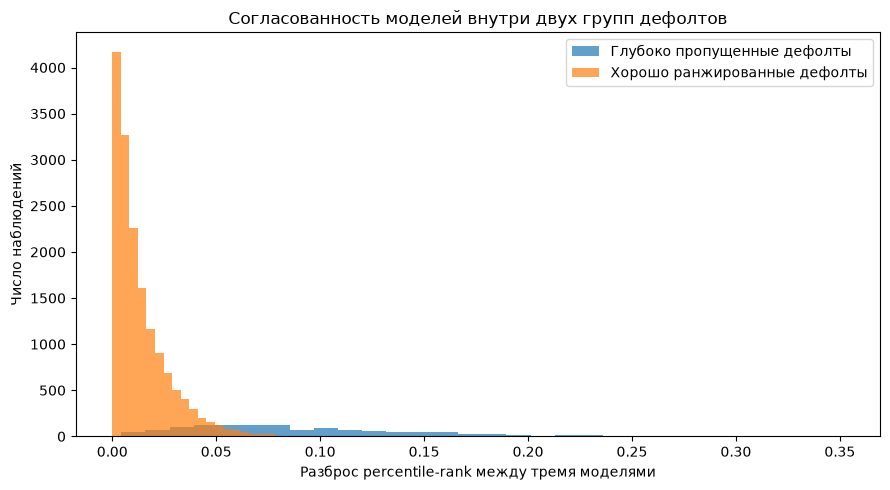

In [8]:
маска_дефолт = ДИАГНОСТИКА["Target"].to_numpy() == 1
маска_недефолт = ~маска_дефолт

маска_глубокий_пропуск = (
    маска_дефолт
    & (CONSENSUS_RANK <= ГРАНИЦА_ГЛУБОКОГО_ПРОПУСКА)
)
маска_хороший_дефолт = (
    маска_дефолт
    & (CONSENSUS_RANK >= ГРАНИЦА_ХОРОШЕГО_ДЕФОЛТА)
)
маска_высокорисковый_недефолт = (
    маска_недефолт
    & (CONSENSUS_RANK >= ГРАНИЦА_ВЫСОКОГО_РИСКА_НЕДЕФОЛТА)
)
маска_общая_слепая_зона = (
    маска_глубокий_пропуск
    & (РАЗБРОС_РАНГОВ <= МАКС_РАЗБРОС_ОБЩЕЙ_СЛЕПОЙ_ЗОНЫ)
)
маска_сильное_расхождение = (
    РАЗБРОС_РАНГОВ >= МИН_РАЗБРОС_СИЛЬНОГО_РАСХОЖДЕНИЯ
)

строки_групп = [
    {
        "Группа": "Глубоко пропущенные дефолты",
        "Число": int(маска_глубокий_пропуск.sum()),
        "Доля от всех дефолтов, %": float(
            маска_глубокий_пропуск.sum() / маска_дефолт.sum() * 100
        ),
    },
    {
        "Группа": "Хорошо ранжированные дефолты",
        "Число": int(маска_хороший_дефолт.sum()),
        "Доля от всех дефолтов, %": float(
            маска_хороший_дефолт.sum() / маска_дефолт.sum() * 100
        ),
    },
    {
        "Группа": "Общая слепая зона",
        "Число": int(маска_общая_слепая_зона.sum()),
        "Доля от всех дефолтов, %": float(
            маска_общая_слепая_зона.sum() / маска_дефолт.sum() * 100
        ),
    },
    {
        "Группа": "Высокорисковые недефолты",
        "Число": int(маска_высокорисковый_недефолт.sum()),
        "Доля от всех дефолтов, %": np.nan,
    },
    {
        "Группа": "Сильное межмодельное расхождение — все строки",
        "Число": int(маска_сильное_расхождение.sum()),
        "Доля от всех дефолтов, %": np.nan,
    },
]

ТАБЛИЦА_ГРУПП = pd.DataFrame(строки_групп)
display(ТАБЛИЦА_ГРУПП.round(2))

доля_общей_зоны_среди_глубоких = float(
    маска_общая_слепая_зона.sum() / max(маска_глубокий_пропуск.sum(), 1)
)

доля_сильного_расхождения_среди_глубоких = float(
    (маска_глубокий_пропуск & маска_сильное_расхождение).sum()
    / max(маска_глубокий_пропуск.sum(), 1)
)

print(
    "Среди глубоко пропущенных дефолтов общая слепая зона: "
    f"{доля_общей_зоны_среди_глубоких:.1%}"
)
print(
    "Среди глубоко пропущенных дефолтов сильное межмодельное расхождение: "
    f"{доля_сильного_расхождения_среди_глубоких:.1%}"
)

plt.figure(figsize=(9, 5))
plt.hist(
    РАЗБРОС_РАНГОВ[маска_глубокий_пропуск],
    bins=30,
    alpha=0.7,
    label="Глубоко пропущенные дефолты",
)
plt.hist(
    РАЗБРОС_РАНГОВ[маска_хороший_дефолт],
    bins=30,
    alpha=0.7,
    label="Хорошо ранжированные дефолты",
)
plt.xlabel("Разброс percentile-rank между тремя моделями")
plt.ylabel("Число наблюдений")
plt.title("Согласованность моделей внутри двух групп дефолтов")
plt.legend()
plt.tight_layout()
plt.show()

### Как читать результат

- Если у большой части глубоко пропущенных дефолтов **маленький разброс rank**, модели ошибаются согласованно. Это совместимо с гипотезой общего информационного пробела.
- Если ошибки в основном сопровождаются большим межмодельным расхождением, часть проблемы может быть связана с модельной спецификой и взаимодействиями уже доступных признаков.

Это всё ещё не доказывает причину ошибки: для причинного вывода текущих данных недостаточно.


# 5. Чем общая слепая зона отличается от хорошо ранжированных дефолтов

## Исследовательский вопрос

Какие из уже доступных признаков сильнее всего различаются между двумя группами дефолтных компаний:

1. общий blind spot;
2. хорошо ранжированные дефолты?

Для сравнения используем **standardized mean difference (SMD)**. Это описательная мера различия распределений, а не feature importance и не причинный эффект.


,Признак,Среднее: слепая зона,Среднее: хорошо ранжированный дефолт,SMD,|SMD|,В Stage 2 top-10
0,Q_A5_norm,13.3884,-56.5001,1.3448,1.3448,True
1,D5_norm,14.4905,-54.1080,1.2021,1.2021,True
2,D4_norm,14.6111,-53.7183,1.1976,1.1976,False
3,Q_D6_norm,13.7023,-32.4404,1.1376,1.1376,True
4,Q_B3_norm,15.6736,-40.1933,0.8949,0.8949,True
5,D1_norm,7.9338,-31.8791,0.8737,0.8737,False
6,Q_C1_norm,9.3776,-27.4799,0.8608,0.8608,True
7,Q_D4_norm,7.9109,-72.3474,0.8400,0.8400,True
8,F1_norm,6.2004,-27.1671,0.7890,0.7890,False
9,D3_norm,7.2931,-31.6053,0.7850,0.7850,False


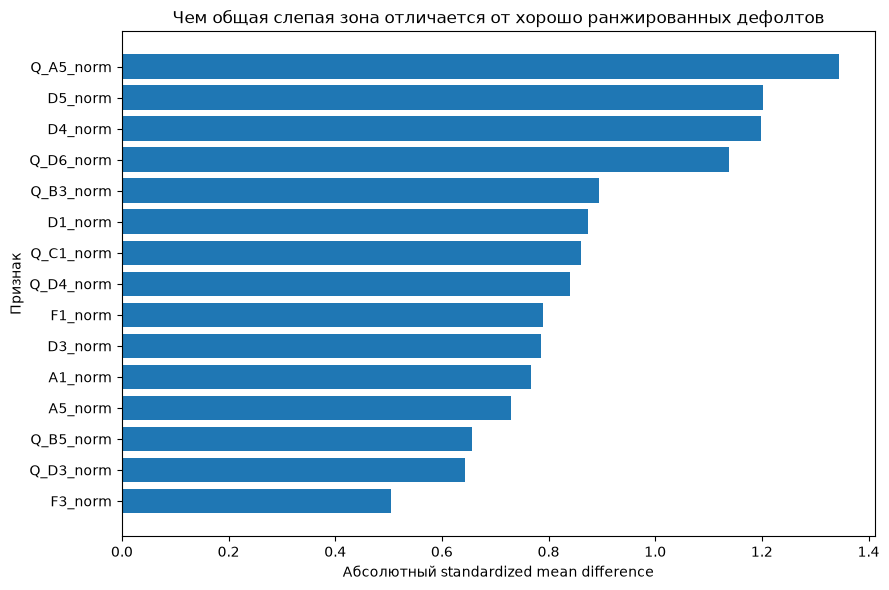

Признаки с сильными различиями вне Stage 2 top-10: D4_norm, D1_norm, F1_norm, D3_norm, A1_norm, A5_norm, Q_B5_norm, Q_D3_norm, F3_norm, E1_norm


In [9]:
def профиль_smd(
    X: pd.DataFrame,
    маска_a: np.ndarray,
    маска_b: np.ndarray,
    название_a: str,
    название_b: str,
) -> pd.DataFrame:
    """Сравнивает две группы по признакам через standardized mean difference."""
    if int(маска_a.sum()) < 2 or int(маска_b.sum()) < 2:
        raise RuntimeError(
            f"Недостаточно наблюдений для сравнения: "
            f"{название_a}={int(маска_a.sum())}, {название_b}={int(маска_b.sum())}."
        )

    строки = []

    for признак in ДОПУСТИМЫЕ_ПРИЗНАКИ:
        a = X.loc[маска_a, признак].to_numpy(dtype=np.float64)
        b = X.loc[маска_b, признак].to_numpy(dtype=np.float64)

        среднее_a = float(np.mean(a))
        среднее_b = float(np.mean(b))
        дисперсия_a = float(np.var(a, ddof=1))
        дисперсия_b = float(np.var(b, ddof=1))
        pooled_std = float(np.sqrt((дисперсия_a + дисперсия_b) / 2))

        smd = (
            float((среднее_a - среднее_b) / pooled_std)
            if pooled_std > 0
            else 0.0
        )

        строки.append({
            "Признак": признак,
            f"Среднее: {название_a}": среднее_a,
            f"Среднее: {название_b}": среднее_b,
            "SMD": smd,
            "|SMD|": abs(smd),
            "В Stage 2 top-10": признак in TOP10_STAGE2,
        })

    return (
        pd.DataFrame(строки)
        .sort_values(["|SMD|", "Признак"], ascending=[False, True])
        .reset_index(drop=True)
    )


ПРОФИЛЬ_СЛЕПОЙ_ЗОНЫ = профиль_smd(
    X_работа,
    маска_общая_слепая_зона,
    маска_хороший_дефолт,
    "слепая зона",
    "хорошо ранжированный дефолт",
)

ТОП_ПРОФИЛЬ = ПРОФИЛЬ_СЛЕПОЙ_ЗОНЫ.head(20).copy()
display(ТОП_ПРОФИЛЬ.round(4))

plot_data = ТОП_ПРОФИЛЬ.head(15).sort_values("|SMD|", ascending=True)
plt.figure(figsize=(9, 6))
plt.barh(plot_data["Признак"], plot_data["|SMD|"])
plt.xlabel("Абсолютный standardized mean difference")
plt.ylabel("Признак")
plt.title("Чем общая слепая зона отличается от хорошо ранжированных дефолтов")
plt.tight_layout()
plt.show()

новые_кандидаты_вне_top10 = (
    ПРОФИЛЬ_СЛЕПОЙ_ЗОНЫ
    .query("`В Stage 2 top-10` == False")
    .head(10)
    ["Признак"]
    .tolist()
)

print(
    "Признаки с сильными различиями вне Stage 2 top-10: "
    + ", ".join(новые_кандидаты_вне_top10)
)

### Интерпретация профилей

Если верхние различия почти полностью состоят из уже ведущих признаков Stage 2, это означает, что baseline **видит эти факторы**, но они не всегда дают достаточно сигнала для корректного ранжирования конкретных дефолтов.

Если среди сильных различий появляются признаки вне Stage 2 top-10, это даёт отдельную гипотезу: возможно, в определённых сегментах модель использует их недостаточно или их влияние требует дополнительного feature engineering.

Ни один из этих вариантов сам по себе не доказывает, что нужно удалить, усилить или трансформировать конкретный признак.


# 6. Высокорисковые недефолты

## Исследовательский вопрос

Отличаются ли компании без дефолта, которые все модели ставят очень высоко по риску, от типичных недефолтных компаний?

Это полезно для будущего бизнес-режима: такие наблюдения потенциально создают нагрузку на ручную проверку и Precision.


,Признак,Среднее: высокорисковый недефолт,Среднее: типичный недефолт,SMD,|SMD|,В Stage 2 top-10
0,Q_A5_norm,-65.1524,6.7947,-1.3618,1.3618,True
1,D5_norm,-63.7401,7.3524,-1.1544,1.1544,True
2,D4_norm,-63.2755,7.3466,-1.1442,1.1442,False
3,Q_D6_norm,-33.3362,-3.6147,-0.7747,0.7747,True
4,F1_norm,-28.2743,0.9790,-0.7145,0.7145,False
5,D3_norm,-35.2277,1.4034,-0.7127,0.7127,False
6,Q_C1_norm,-29.5782,-1.2795,-0.7080,0.7080,True
7,Q_B3_norm,-36.6891,8.9799,-0.6995,0.6995,True
8,Q_D4_norm,-46.2092,5.4327,-0.6262,0.6262,True
9,D1_norm,-30.2169,-2.7521,-0.5943,0.5943,False


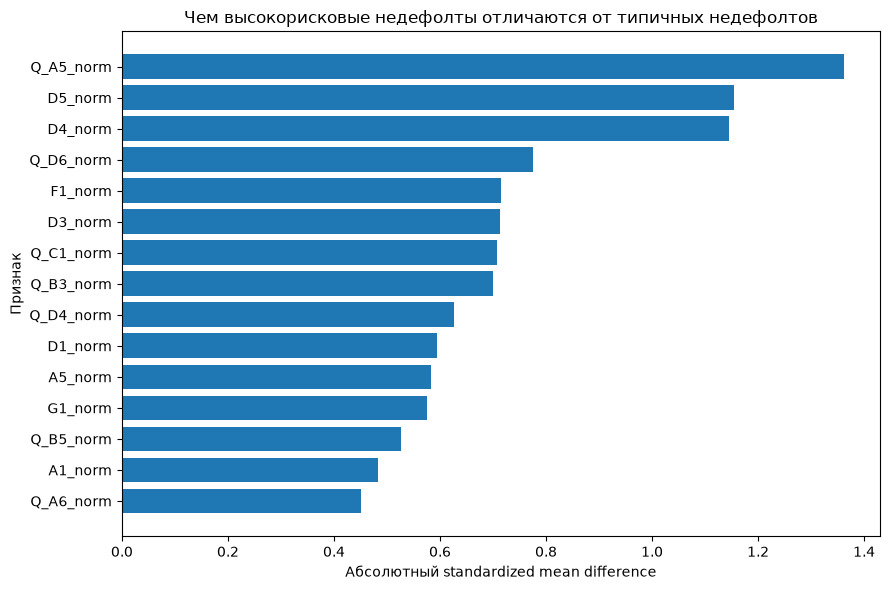

In [10]:
маска_типичный_недефолт = (
    маска_недефолт
    & (CONSENSUS_RANK >= 0.40)
    & (CONSENSUS_RANK <= 0.60)
)

ПРОФИЛЬ_ВЫСОКОГО_РИСКА_НЕДЕФОЛТ = профиль_smd(
    X_работа,
    маска_высокорисковый_недефолт,
    маска_типичный_недефолт,
    "высокорисковый недефолт",
    "типичный недефолт",
)

display(ПРОФИЛЬ_ВЫСОКОГО_РИСКА_НЕДЕФОЛТ.head(20).round(4))

plot_data = (
    ПРОФИЛЬ_ВЫСОКОГО_РИСКА_НЕДЕФОЛТ
    .head(15)
    .sort_values("|SMD|", ascending=True)
)

plt.figure(figsize=(9, 6))
plt.barh(plot_data["Признак"], plot_data["|SMD|"])
plt.xlabel("Абсолютный standardized mean difference")
plt.ylabel("Признак")
plt.title("Чем высокорисковые недефолты отличаются от типичных недефолтов")
plt.tight_layout()
plt.show()

### Ограничение

Фактический `DefMark = 0` не означает, что высокий прогноз модели обязательно является «ошибкой бизнеса»: возможно, компания действительно была близка к дефолту или имела риск-факторы, которые не реализовались в горизонте наблюдения.

Поэтому эту группу используем как диагностический сегмент, а не как доказанный набор false positives в экономическом смысле.


# 7. Сохранение OOF-checkpoint и результатов

## Зачем сохраняем OOF

Stage 3 впервые сохраняет row-level OOF-прогнозы трёх baseline-моделей в локальный `.npz` без `INN` и без final test. Это позволит следующим исследованиям не переобучать baseline только ради повторного анализа тех же OOF-score.

Файл остаётся в `reports/generated/` и не отслеживается Git.


In [11]:
ПУТЬ_OOF = ПАПКА_ОТЧЁТОВ / "stage3_oof_predictions_V1.npz"
ПУТЬ_JSON = ПАПКА_ОТЧЁТОВ / "stage3_error_analysis_results_V1.json"
ПУТЬ_ПРОФИЛЕЙ = ПАПКА_ОТЧЁТОВ / "stage3_error_feature_profiles_V1.csv"
ПУТЬ_ГРУПП = ПАПКА_ОТЧЁТОВ / "stage3_error_cohorts_V1.csv"

np.savez_compressed(
    ПУТЬ_OOF,
    working_indices=np.asarray(индексы_работа, dtype=np.int64),
    target=y_работа.to_numpy(dtype=np.int8),
    oof_catboost=OOF_ПРОГНОЗЫ["CatBoost"],
    oof_xgboost=OOF_ПРОГНОЗЫ["XGBoost"],
    oof_lightgbm=OOF_ПРОГНОЗЫ["LightGBM"],
    consensus_rank=CONSENSUS_RANK,
    rank_spread=РАЗБРОС_РАНГОВ,
)

SHA_OOF = вычислить_sha256(ПУТЬ_OOF)

профили_для_csv = pd.concat([
    ПРОФИЛЬ_СЛЕПОЙ_ЗОНЫ.assign(
        Сравнение="Общая слепая зона vs хорошо ранжированные дефолты"
    ),
    ПРОФИЛЬ_ВЫСОКОГО_РИСКА_НЕДЕФОЛТ.assign(
        Сравнение="Высокорисковые недефолты vs типичные недефолты"
    ),
], ignore_index=True)

профили_для_csv.to_csv(
    ПУТЬ_ПРОФИЛЕЙ,
    index=False,
    encoding="utf-8-sig",
)
ТАБЛИЦА_ГРУПП.to_csv(
    ПУТЬ_ГРУПП,
    index=False,
    encoding="utf-8-sig",
)

версии = {
    пакет: importlib_metadata.version(пакет)
    for пакет in [
        "numpy",
        "pandas",
        "scikit-learn",
        "pyxlsb",
        "catboost",
        "xgboost",
        "lightgbm",
        "matplotlib",
    ]
}

результат = {
    "исследовательский_вопрос": (
        "Есть ли устойчивые группы OOF-ошибок, одинаковые для CatBoost, "
        "XGBoost и LightGBM, и чем общие слепые зоны отличаются по доступным признакам?"
    ),
    "dataset": {
        "sha256": фактический_sha256,
        "строк": len(данные),
        "допустимых_признаков": len(ДОПУСТИМЫЕ_ПРИЗНАКИ),
        "исключённые_признаки": ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ,
    },
    "split": {
        "sha256_индексов_работа": SHA_ИНДЕКСОВ_РАБОТА,
        "sha256_индексов_test": SHA_ИНДЕКСОВ_TEST,
        "final_test_использован": False,
        "число_фолдов": ЧИСЛО_ФОЛДОВ,
        "seed": СЛУЧАЙНОЕ_ЗЕРНО,
    },
    "воспроизведение_stage1_v2": ТАБЛИЦА_ВОСПРОИЗВЕДЕНИЯ.to_dict(orient="records"),
    "диагностические_границы": {
        "глубоко_пропущенный_дефолт_consensus_rank_lte": ГРАНИЦА_ГЛУБОКОГО_ПРОПУСКА,
        "хорошо_ранжированный_дефолт_consensus_rank_gte": ГРАНИЦА_ХОРОШЕГО_ДЕФОЛТА,
        "высокорисковый_недефолт_consensus_rank_gte": ГРАНИЦА_ВЫСОКОГО_РИСКА_НЕДЕФОЛТА,
        "общая_слепая_зона_rank_spread_lte": МАКС_РАЗБРОС_ОБЩЕЙ_СЛЕПОЙ_ЗОНЫ,
        "сильное_межмодельное_расхождение_rank_spread_gte": МИН_РАЗБРОС_СИЛЬНОГО_РАСХОЖДЕНИЯ,
    },
    "группы": (
        ТАБЛИЦА_ГРУПП.astype(object)
        .where(pd.notna(ТАБЛИЦА_ГРУПП), None)
        .to_dict(orient="records")
    ),
    "доля_общей_слепой_зоны_среди_глубоких_пропусков": доля_общей_зоны_среди_глубоких,
    "доля_сильного_расхождения_среди_глубоких_пропусков": доля_сильного_расхождения_среди_глубоких,
    "захват_дефолтов": {
        "top_10pct": захват_top10,
        "top_20pct": захват_top20,
        "top_30pct": захват_top30,
    },
    "top20_профиль_слепой_зоны": ТОП_ПРОФИЛЬ.to_dict(orient="records"),
    "top20_высокорисковые_недефолты": (
        ПРОФИЛЬ_ВЫСОКОГО_РИСКА_НЕДЕФОЛТ.head(20).to_dict(orient="records")
    ),
    "stage2_top10": TOP10_STAGE2,
    "oof_checkpoint": {
        "filename": ПУТЬ_OOF.name,
        "sha256": SHA_OOF,
        "содержит_inn": False,
        "содержит_final_test": False,
    },
    "параметры_моделей": ПАРАМЕТРЫ_МОДЕЛЕЙ,
    "версии_библиотек": версии,
    "время_воспроизведения_oof_сек": ОБЩЕЕ_ВРЕМЯ_ОБУЧЕНИЯ,
}

with ПУТЬ_JSON.open("w", encoding="utf-8") as файл:
    json.dump(результат, файл, ensure_ascii=False, indent=2)

print("Сохранено:")
print("-", ПУТЬ_JSON)
print("-", ПУТЬ_ПРОФИЛЕЙ)
print("-", ПУТЬ_ГРУПП)
print("-", ПУТЬ_OOF)
print("SHA-256 OOF checkpoint:", SHA_OOF)

Сохранено:
- D:\Projects\komus-credit-risk\reports\generated\stage3_error_analysis_results_V1.json
- D:\Projects\komus-credit-risk\reports\generated\stage3_error_feature_profiles_V1.csv
- D:\Projects\komus-credit-risk\reports\generated\stage3_error_cohorts_V1.csv
- D:\Projects\komus-credit-risk\reports\generated\stage3_oof_predictions_V1.npz
SHA-256 OOF checkpoint: faa53a8aed86c2d445699c0fd1df6a5b83711c96d3a300f9a8860112ff4473ac


# 8. Итог Stage 3 V1

## ФАКТЫ / ИНТЕРПРЕТАЦИЯ / ОГРАНИЧЕНИЯ / СЛЕДУЮЩИЙ ШАГ

Следующая ячейка формирует итог только из фактически рассчитанных значений. После запуска именно этот блок и JSON являются основой для решения, какой feature-engineering эксперимент делать следующим.


In [12]:
top10_smd = ТОП_ПРОФИЛЬ.head(10)["Признак"].tolist()

print("ФАКТЫ")
print("-" * 72)
print(f"Всего дефолтов в working sample: {int(маска_дефолт.sum())}")
print(
    "Глубоко пропущенных дефолтов: "
    f"{int(маска_глубокий_пропуск.sum())} "
    f"({маска_глубокий_пропуск.sum() / маска_дефолт.sum():.1%} от всех дефолтов)"
)
print(
    "Общая слепая зона: "
    f"{int(маска_общая_слепая_зона.sum())} "
    f"({доля_общей_зоны_среди_глубоких:.1%} от глубоко пропущенных дефолтов)"
)
print(
    "Сильное межмодельное расхождение среди глубоко пропущенных: "
    f"{доля_сильного_расхождения_среди_глубоких:.1%}"
)
print(f"Захват дефолтов в top-10% риска: {захват_top10:.1%}")
print(f"Захват дефолтов в top-20% риска: {захват_top20:.1%}")
print(f"Захват дефолтов в top-30% риска: {захват_top30:.1%}")
print("Top-10 признаков по |SMD| слепой зоны:", ", ".join(top10_smd))

print("\nИНТЕРПРЕТАЦИЯ")
print("-" * 72)
print(
    "Чем выше доля общей слепой зоны среди глубоко пропущенных дефолтов, "
    "тем сильнее свидетельство, что проблема общая для трёх моделей, "
    "а не специфична для одного алгоритма."
)
print(
    "Профиль SMD показывает, какие доступные признаки отличают такие случаи, "
    "но не объясняет причинность и не доказывает, какой новый внешний фактор нужен."
)

print("\nОГРАНИЧЕНИЯ")
print("-" * 72)
print("- Random split не доказывает temporal stability.")
print("- Границы диагностических групп не являются рабочим threshold.")
print("- SMD — описательная мера, а не feature importance и не causal effect.")
print("- Final test не использован.")
print("- Анализ не доказывает существование конкретного внешнего недостающего фактора.")

print("\nСЛЕДУЮЩИЙ ШАГ")
print("-" * 72)
print(
    "После review фактических групп и feature-профилей выбираем одну первую "
    "гипотезу feature engineering и сравниваем её с baseline 0.804 "
    "на том же working/CV-протоколе без открытия final test."
)

ФАКТЫ
------------------------------------------------------------------------
Всего дефолтов в working sample: 28015
Глубоко пропущенных дефолтов: 1278 (4.6% от всех дефолтов)
Общая слепая зона: 805 (63.0% от глубоко пропущенных дефолтов)
Сильное межмодельное расхождение среди глубоко пропущенных: 1.9%
Захват дефолтов в top-10% риска: 57.2%
Захват дефолтов в top-20% риска: 77.8%
Захват дефолтов в top-30% риска: 87.4%
Top-10 признаков по |SMD| слепой зоны: Q_A5_norm, D5_norm, D4_norm, Q_D6_norm, Q_B3_norm, D1_norm, Q_C1_norm, Q_D4_norm, F1_norm, D3_norm

ИНТЕРПРЕТАЦИЯ
------------------------------------------------------------------------
Чем выше доля общей слепой зоны среди глубоко пропущенных дефолтов, тем сильнее свидетельство, что проблема общая для трёх моделей, а не специфична для одного алгоритма.
Профиль SMD показывает, какие доступные признаки отличают такие случаи, но не объясняет причинность и не доказывает, какой новый внешний фактор нужен.

ОГРАНИЧЕНИЯ
------------------